# 🛢️ Notebook 01 — Delaware Basin Polygon & Well Inventory

**Project:** Texas Injection Wells — Delaware Basin Analysis  
**Author:** Juan David Antolinez  
**Purpose:** Download the Delaware Basin boundary from the EIA, clip it to Texas, and identify all injection wells located within the polygon using the Texas RRC open data API.

---

### Workflow
1. Download Delaware Basin shapefile from EIA (automatic)
2. Clip polygon to Texas boundary (lat ≤ 32.0)
3. Download all Texas RRC wells with coordinates via Socrata API
4. Spatial filter — keep only wells inside the Delaware Basin polygon
5. Save results for downstream notebooks

### Outputs
- `shapefiles/delaware_texas.shp` — clipped polygon
- `shapefiles/wells_delaware.shp` — wells inside polygon
- `data/raw/wells_delaware_coordinates.csv` — wells with coordinates (for Power BI)

## 1. Library Imports|

In [1]:
import pandas as pd
import requests
import zipfile
import geopandas as gpd
from pathlib import Path
import io
import contextily as ctx
import matplotlib.pyplot as plt
from shapely.geometry import box
from sodapy import Socrata

## 2. Project Paths

All paths are relative to the project root — no hardcoded local paths. This ensures the notebook runs on any machine after cloning the repository.

In [2]:
BASE_DIR = Path.cwd().parent
DATA_RAW    = BASE_DIR / "data" / "raw"
SHAPEFILES  = BASE_DIR / "shapefiles"

## 3. Download Delaware Basin Shapefile (EIA)

The boundary is sourced from the U.S. Energy Information Administration (EIA) open data portal.  
The file is downloaded automatically — no manual download required.

> **Source:** https://www.eia.gov/maps/map_data/ShalePlay_Delaware_EIA.zip

In [3]:
URL_SHAPEFILE = "https://www.eia.gov/maps/map_data/ShalePlay_Delaware_EIA.zip"

# Download ZIP file
response = requests.get(URL_SHAPEFILE)
print(f"Download status: {response.status_code} — {'OK' if response.status_code == 200 else 'FAILED'}")

# Extract contents to shapefiles folder
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall(SHAPEFILES)
    print(f"Extracted {len(z.namelist())} files to: {SHAPEFILES}")

Download status: 200 — OK
Extracted 8 files to: g:\My Drive\Portafolio analisis de datos\texas-injection-wells\shapefiles


## 4. Clip Polygon to Texas

The EIA Delaware Basin polygon spans both Texas and New Mexico.  
We clip it to Texas only using a bounding box with `latitude ≤ 32.0` (Texas–New Mexico border).

In [4]:
# Load original shapefile
gdf = gpd.read_file(SHAPEFILES / "ShalePlay_Delaware_Boundary_EIA_201909.shp")
print(f"Original polygon — rows: {len(gdf)}, CRS: {gdf.crs}")

# Define Texas bounding box (lat <= 32.0)
texas_bbox = box(-104.5, 31.0, -103.0, 32.0)

# Clip to Texas
gdf_texas = gdf.clip(texas_bbox)
print(f"Clipped polygon — rows: {len(gdf_texas)}")

Original polygon — rows: 1, CRS: EPSG:4326
Clipped polygon — rows: 1


### 4.1 Visualize — Delaware Basin (Texas Only)

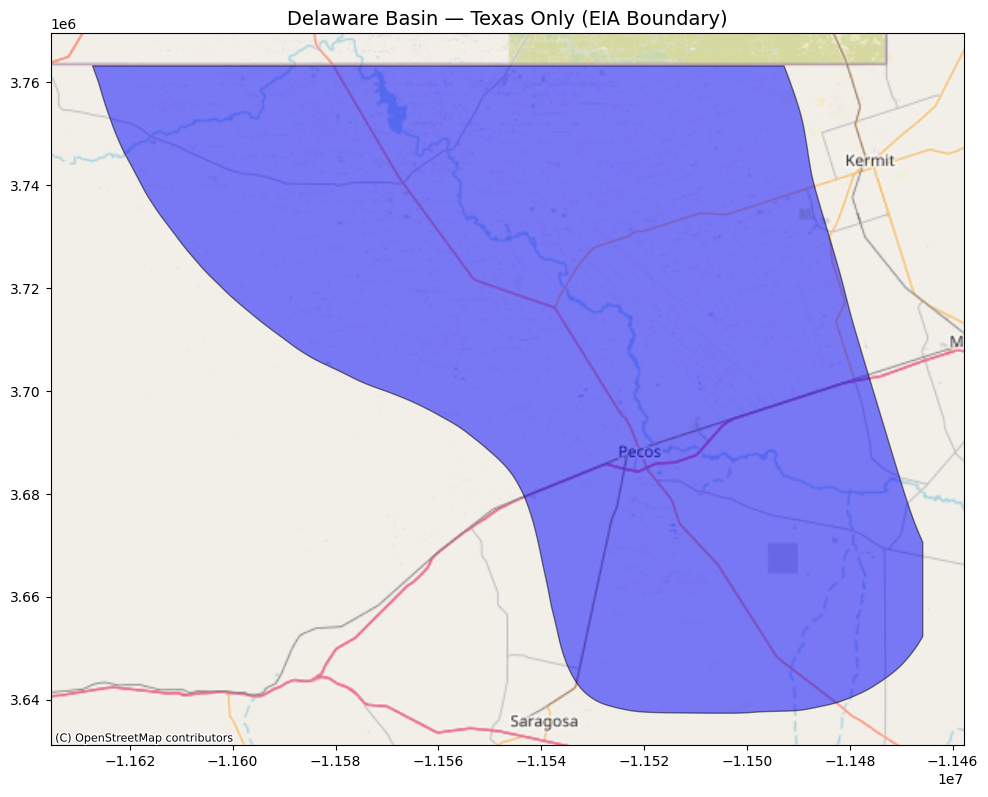

In [5]:
gdf_texas_web = gdf_texas.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_texas_web.plot(ax=ax, alpha=0.5, color="blue", edgecolor="black")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Delaware Basin — Texas Only (EIA Boundary)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Download Wells from Texas RRC (Socrata API)

The Texas Railroad Commission publishes well location data through the Texas Open Data Portal (Socrata).  
We download all wells with coordinates — up to 200,000 records — and then filter spatially.

> **Dataset ID:** `givw-z9t4` — Texas RRC Well Locations  
> **Portal:** https://data.texas.gov

In [6]:
# Connect to Texas Open Data portal (no API key required)
client = Socrata("data.texas.gov", None)

# Download all wells with coordinates
results = client.get(
    "givw-z9t4",
    limit=200000
)

# Convert to DataFrame
results_df = pd.DataFrame.from_records(results)

# Convert coordinates from string to numeric
results_df['latitude_nad83']  = pd.to_numeric(results_df['latitude_nad83'])
results_df['longitude_nad83'] = pd.to_numeric(results_df['longitude_nad83'])

print(f"Total wells downloaded: {len(results_df):,}")

Total wells downloaded: 126,589


## 6. Spatial Filter — Wells Inside Delaware Basin

Convert the wells DataFrame to a GeoDataFrame and perform a spatial join to keep only wells located inside the Delaware Basin polygon.

In [7]:
# Convert to GeoDataFrame
wells_gdf = gpd.GeoDataFrame(
    results_df,
    geometry=gpd.points_from_xy(results_df['longitude_nad83'], results_df['latitude_nad83']),
    crs="EPSG:4326"
)

# Spatial join — keep only wells inside the polygon
wells_delaware = gpd.sjoin(wells_gdf, gdf_texas, how="inner", predicate="within")

print(f"Total Texas wells:            {len(wells_gdf):,}")
print(f"Wells inside Delaware Basin:  {len(wells_delaware):,}")

Total Texas wells:            126,589
Wells inside Delaware Basin:  2,872


### 6.1 Visualize — Injection Wells Inside Delaware Basin

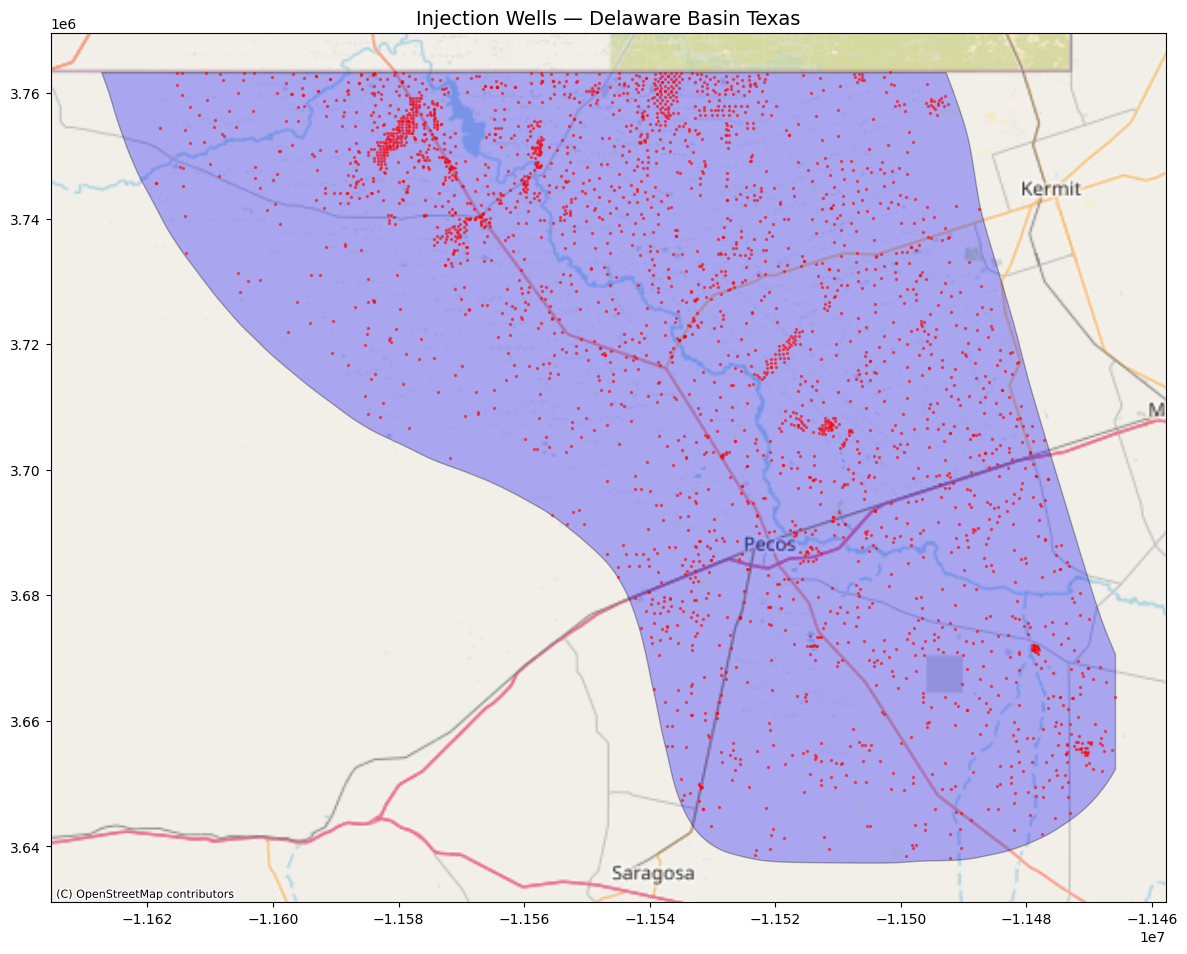

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot polygon
gdf_texas.to_crs(epsg=3857).plot(ax=ax, alpha=0.3, color="blue", edgecolor="black")

# Plot wells
wells_delaware.to_crs(epsg=3857).plot(ax=ax, markersize=2, color="red", alpha=0.5)

# Basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Injection Wells — Delaware Basin Texas", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Save Outputs

Save the clipped polygon and filtered wells for use in downstream notebooks.

In [9]:
# Save clipped polygon
gdf_texas.to_file(SHAPEFILES / "delaware_texas.shp")

# Save wells as shapefile
wells_delaware.to_file(SHAPEFILES / "wells_delaware.shp")

# Save wells as CSV (used in Power BI and georeferencing)
wells_delaware.drop(columns='geometry').to_csv(
    DATA_RAW / "wells_delaware_coordinates.csv", index=False
)

print(f"✅ Polygon saved:  {SHAPEFILES / 'delaware_texas.shp'}")
print(f"✅ Wells saved:    {SHAPEFILES / 'wells_delaware.shp'}")
print(f"✅ CSV saved:      {DATA_RAW / 'wells_delaware_coordinates.csv'}")

C:\Users\juand\AppData\Local\Temp\ipykernel_160024\2008669648.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  wells_delaware.to_file(SHAPEFILES / "wells_delaware.shp")
c:\Users\juand\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'oil_gas_code' to 'oil_gas_co'
  ogr_write(
c:\Users\juand\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'district_code' to 'district_c'
  ogr_write(
c:\Users\juand\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'lease_number' to 'lease_numb'
  ogr_write(
c:\Users\juand\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'well_no_display' to 'well_no_di'
  ogr_write(
c:\Users\juand\AppData\L

✅ Polygon saved:  g:\My Drive\Portafolio analisis de datos\texas-injection-wells\shapefiles\delaware_texas.shp
✅ Wells saved:    g:\My Drive\Portafolio analisis de datos\texas-injection-wells\shapefiles\wells_delaware.shp
✅ CSV saved:      g:\My Drive\Portafolio analisis de datos\texas-injection-wells\data\raw\wells_delaware_coordinates.csv
